In [13]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.visualization import simple_norm
import astropy.units as u
import astropy.wcs as wcs
from astropy.io import fits

import glob
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f1500w": "/orange/adamginsburg/jwst/w51/F1500W/pipeline/jw06151-o002_t001_miri_f1500w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
   
}
def get_table(temp=3000):
    fns = glob.glob(f'/blue/adamginsburg/t.yoo/from_red/w51/w51_catalog/syn_star/saved_data/syn_stars_{temp}*.fits')
    if len(fns)==0:
        raise ValueError(f'No files found norm temp={temp}')
    for ii,fn in enumerate(fns):
        tab = Table.read(fn)
        if ii==0:
            full_tab = tab
        else:
            full_tab = vstack([full_tab, tab])
    return full_tab



In [ ]:
"""
def get_line_excess(data_narrow, data_wide, narrow, wide):
    from astroquery.svo_fps import SvoFps
    import numpy as np
    from astropy.wcs import WCS
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))
    #data_narrow = (flux_narrow * u.MJy/u.sr * ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    #data_wide = (flux_wide * u.MJy/u.sr * ww_wide.proj_plane_pixel_area()).to(u.Jy)

    wavelength_table_narrow = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    wavelength_table_wide = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    waves_wide = wavelength_table_wide['Wavelength']
    trans_narrow = np.interp(waves_wide, wavelength_table_narrow['Wavelength'], wavelength_table_narrow['Transmission'])
    trans_wide = wavelength_table_wide['Transmission']


    fractional_bandwidth = ( (trans_wide/trans_wide.max()) * (trans_narrow/trans_narrow.max()) ).sum() / (trans_wide/trans_wide.max()).sum()
    #print(f'Fractional bandwidth: {fractional_bandwidth}')
    if fractional_bandwidth == 1:
        print("The filters either have no overlap or are identical. Exiting")
        return


    wide_minus_narrow = (data_wide - data_narrow * fractional_bandwidth) / (1-fractional_bandwidth)
    #return wide_minus_narrow

    narrow_minus_wide = data_narrow - wide_minus_narrow
    #narrow_minus_wide = (data_narrow - data_wide * fractional_bandwidth) / (1-fractional_bandwidth)
    return np.array(narrow_minus_wide)
"""



In [15]:
print(all_phot_result['wavelength'])
subset_187 = all_phot_result[(all_phot_result['wavelength'] == 187)]
f187n_flux_all = subset_187['flux_fit']
subset_182 = all_phot_result[(all_phot_result['wavelength'] == 182)]
f182m_flux_all = subset_182['flux_fit']
print(len(f187n_flux_all), len(f182m_flux_all))
print(f187n_flux_all)

wavelength
----------
     140.0
     162.0
     182.0
     187.0
     140.0
     162.0
     182.0
     187.0
     140.0
     162.0
       ...
     182.0
     187.0
     140.0
     162.0
     182.0
     187.0
     140.0
     162.0
     182.0
     187.0
Length = 120 rows
30 30
       flux_fit       
----------------------
 6.917525740255381e-05
  0.006917525740255414
 5.906139052697311e-05
  0.002773073528161495
 6.917525740255402e-07
2.7730735281614936e-05
1.3139328006516457e-06
1.4736544042166473e-08
2.4957661753453477e-06
 0.0002495766175345345
                   ...
1.9174823977583792e-05
  0.001459925334057385
1.6373937824629402e-07
  5.31552514742759e-06
 5.906139052697308e-07
 7.686139711394872e-06
5.3155251474276014e-08
0.00021305359975093148
0.00013139328006516495
  0.013139328006516442
Length = 30 rows


       flux_fit       
----------------------
 6.917525740255381e-05
  0.006917525740255414
 5.906139052697311e-05
  0.002773073528161495
 6.917525740255402e-07
2.7730735281614936e-05
1.3139328006516457e-06
1.4736544042166473e-08
2.4957661753453477e-06
 0.0002495766175345345
                   ...
1.9174823977583792e-05
  0.001459925334057385
1.6373937824629402e-07
  5.31552514742759e-06
 5.906139052697308e-07
 7.686139711394872e-06
5.3155251474276014e-08
0.00021305359975093148
0.00013139328006516495
  0.013139328006516442
Length = 30 rows


Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/scratch

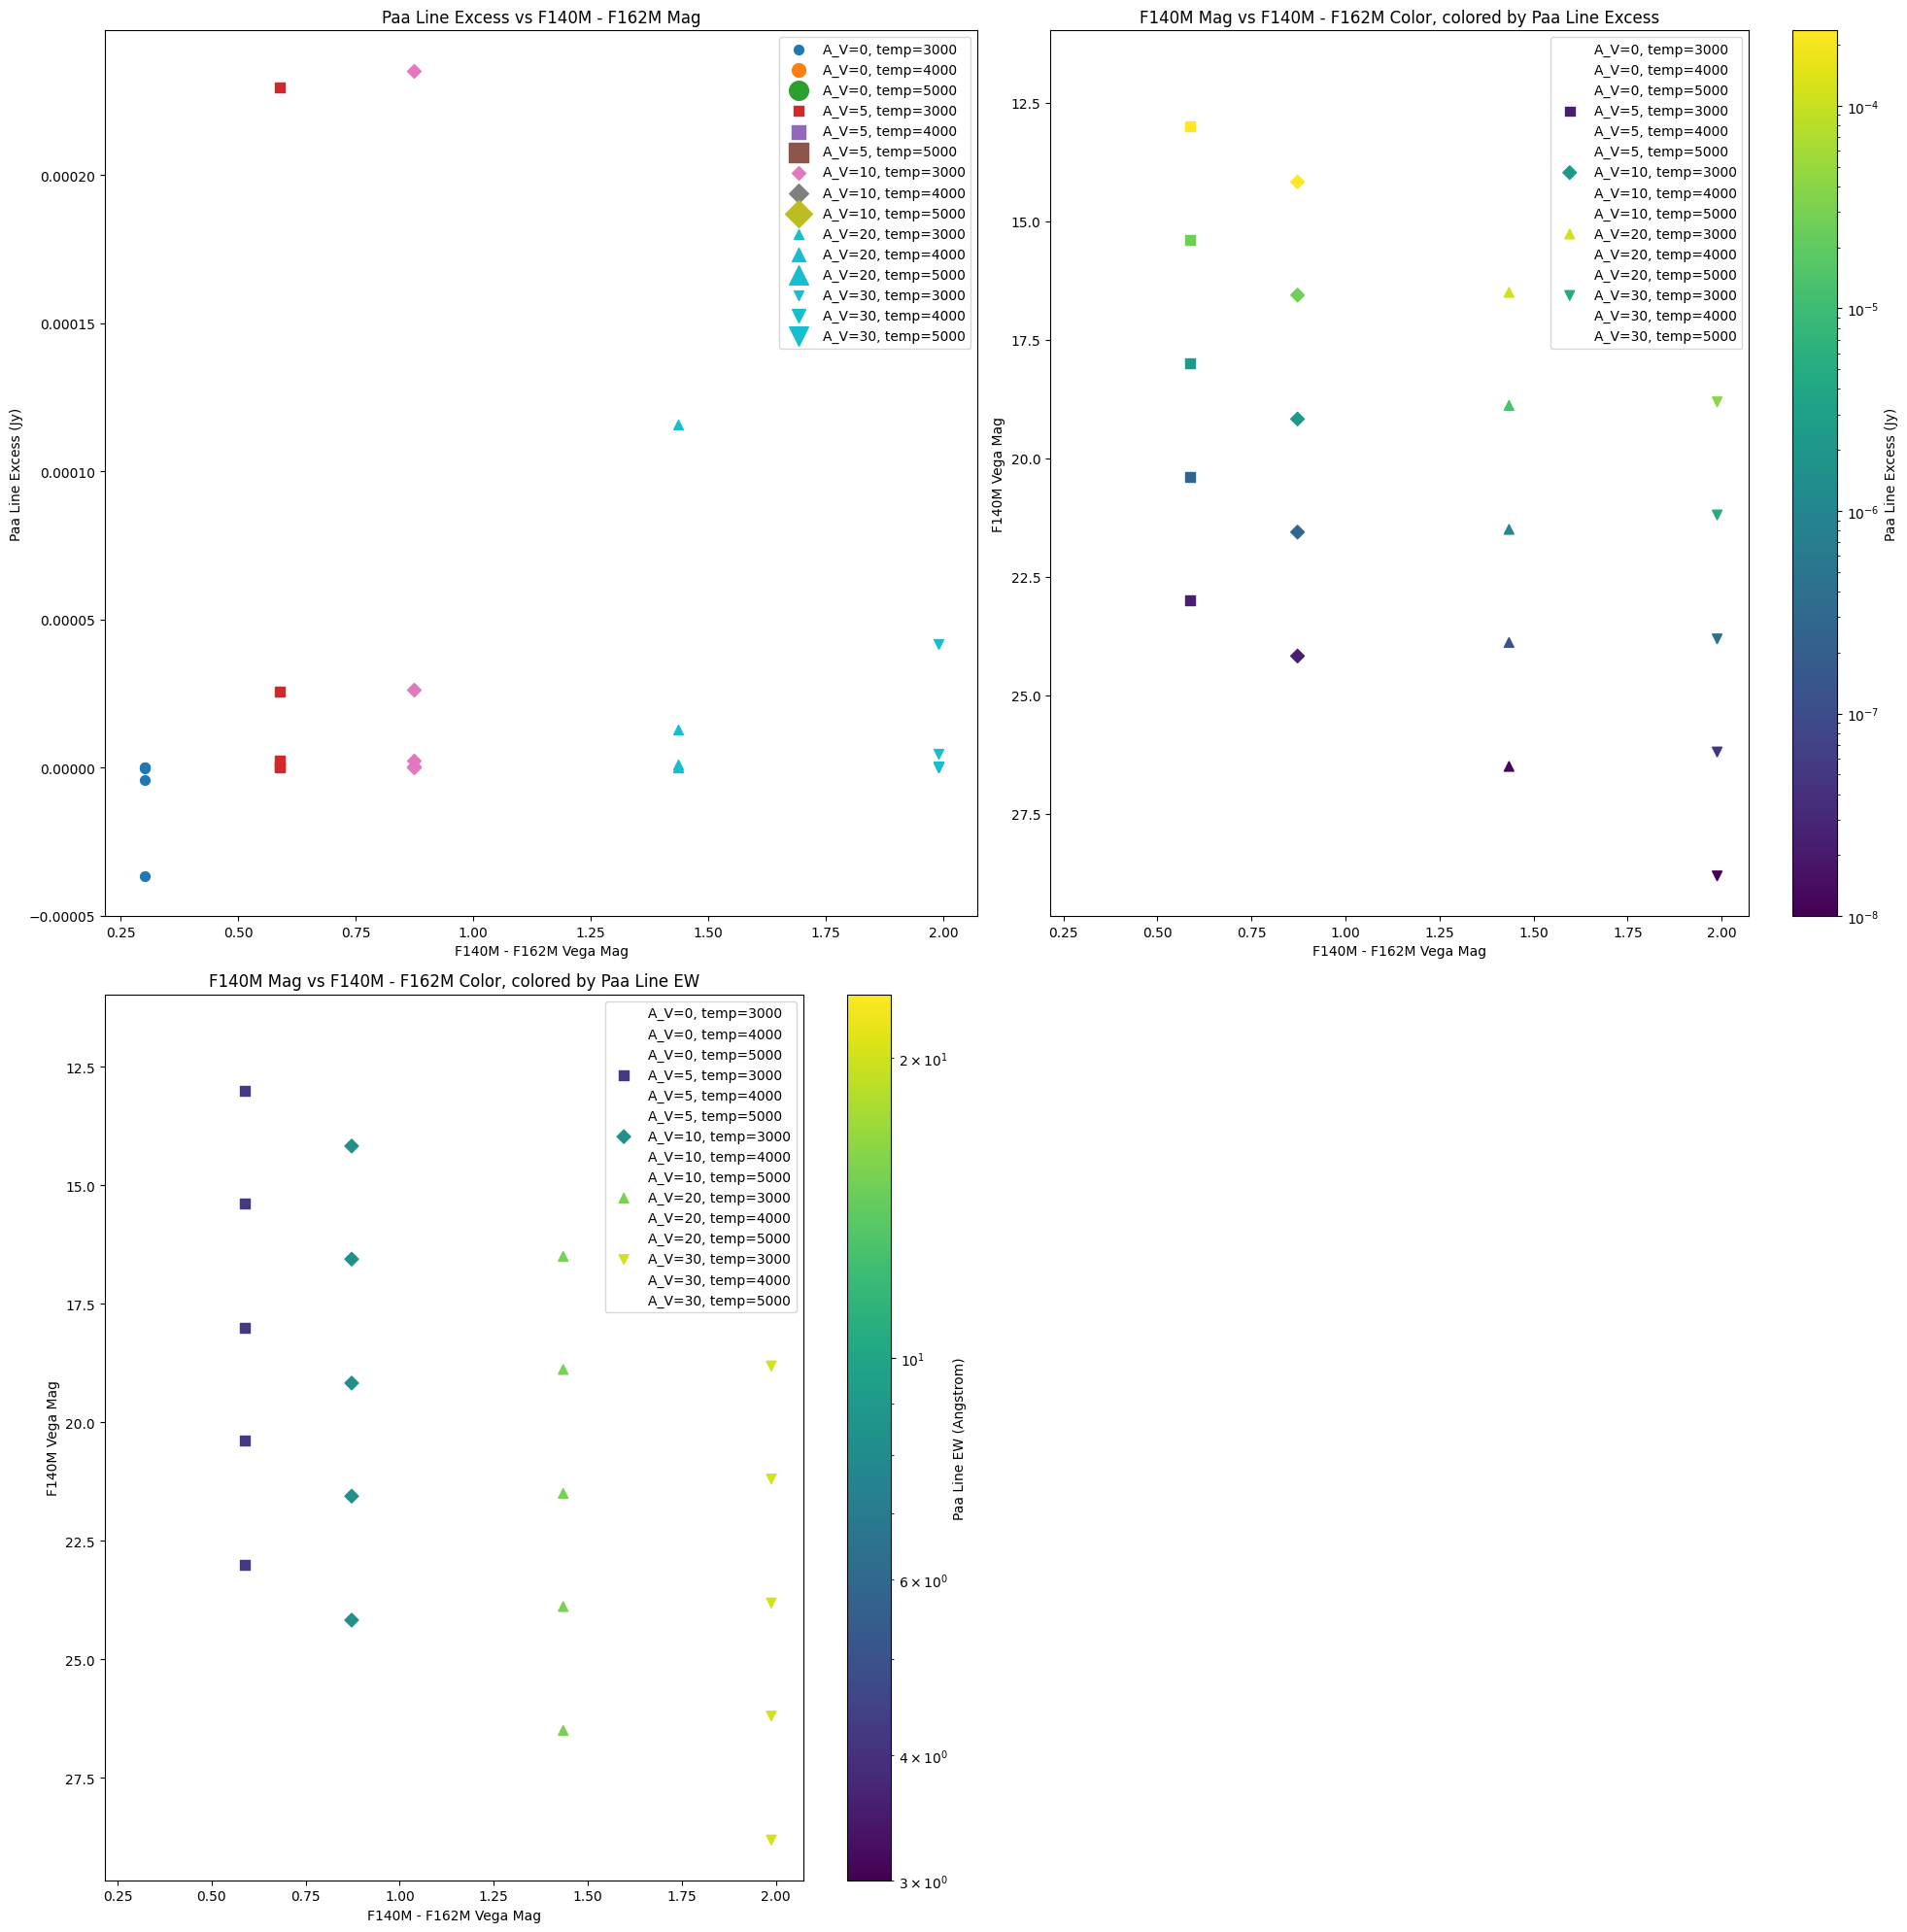

In [61]:
def get_line_excess(data_narrow, data_wide,narrow, wide):
    # --- Convert catalog MJy/sr → Jy ---
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))

    

    # --- Load filter curves ---
    tab_n = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    tab_w = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    wave_n = tab_n['Wavelength'] * u.AA
    trans_n = tab_n['Transmission']

    wave_w = tab_w['Wavelength'] * u.AA
    trans_w = tab_w['Transmission']

    # --- Interpolate narrow onto wide grid ---
    trans_n_interp = np.interp(wave_w.value, wave_n.value, trans_n)

    # --- Fractional overlap (proper integral) ---
    num = np.trapezoid(
    (trans_w / trans_w.max()) * (trans_n_interp / trans_n.max()),
    wave_w.value
    )
    den = np.trapezoid(trans_w / trans_w.max(), wave_w.value)
    f = num / den

    if np.isclose(f, 1.0):
        return None, None

    # --- Continuum & line (still in Jy = F_nu) ---
    cont_nu = (data_wide - data_narrow * f) / (1 - f)
    line_nu = data_narrow - cont_nu

    width_narrow = np.trapezoid(trans_n / trans_n.max(), wave_n.value) * u.AA

    # --- Equivalent Width ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ew = (line_nu / cont_nu) * width_narrow

    return line_nu.value, ew.to_value(u.AA)
all_phot_result = get_table(temp=3000)
from matplotlib.colors import LogNorm
fig = plt.figure(figsize=(20, 20))
A_V_list = [0, 5, 10, 20, 30, 40]
temp_list = [3000, 4000, 5000, 6000]
ax1 = fig.add_subplot(2,2, 1)
ax2 = fig.add_subplot(2,2, 2)
ax3 = fig.add_subplot(2,2, 3)
cmap = plt.get_cmap('tab10')
color_index = 0
print(f187n_flux_all)
paa_excess_all, paa_ew_all = get_line_excess(f187n_flux_all, f182m_flux_all, narrow='f187n', wide='f182m')
color_index = 0
sizelist = [50, 100, 200]
markerlist = ['o', 's', 'D', '^', 'v']
cmap2 = plt.get_cmap('viridis')
norm = LogNorm(vmin=1e-8, vmax=paa_excess_all.max())
norm_ew = LogNorm(vmin=3, vmax=np.nanmax(paa_ew_all))
color_cmd_list = []
mag_cmd_list = []
paa_excess_list = []
for A_V, marker in zip(A_V_list, markerlist):
    for temp, size in zip(temp_list, sizelist):
        subset = all_phot_result[(all_phot_result['A_V'] == A_V) & (all_phot_result['temp'] == temp) & (all_phot_result['wavelength'] == 140)]
        f140m_mag = subset['mag_fit']
        subset = all_phot_result[(all_phot_result['A_V'] == A_V) & (all_phot_result['temp'] == temp) & (all_phot_result['wavelength'] == 162)]
        f162m_mag = subset['mag_fit']
        subset = all_phot_result[(all_phot_result['A_V'] == A_V) & (all_phot_result['temp'] == temp) & (all_phot_result['wavelength'] == 187)]
        f187n_flux = subset['flux_fit']
        subset = all_phot_result[(all_phot_result['A_V'] == A_V) & (all_phot_result['temp'] == temp) & (all_phot_result['wavelength'] == 182)]
        f182m_flux = subset['flux_fit']
        paa_excess, paa_ew = get_line_excess(f187n_flux, f182m_flux, narrow='f187n', wide='f182m')
       # print(len(paa_excess), len(f140m_mag))
        ax1.scatter( f140m_mag-f162m_mag, paa_excess, label=f"A_V={A_V}, temp={temp}", c=cmap(color_index), marker=marker, s=size)
        ax2.scatter( f140m_mag-f162m_mag, f140m_mag, label=f"A_V={A_V}, temp={temp}", c=paa_excess, marker=marker, s=size, norm=norm, cmap=cmap2)
        ax3.scatter( f140m_mag-f162m_mag, f140m_mag, label=f"A_V={A_V}, temp={temp}", c=paa_ew, marker=marker, s=size, norm=norm_ew, cmap=cmap2)
        color_index += 1
        color_cmd_list.append(f140m_mag-f162m_mag)
        mag_cmd_list.append(f140m_mag)
        paa_excess_list.append(np.log10(paa_excess))
ax1.set_xlabel('F140M - F162M Vega Mag')
ax1.set_ylabel('Paa Line Excess (Jy)')
ax1.set_title('Paa Line Excess vs F140M - F162M Mag')

ax1.legend()

ax2.set_xlabel('F140M - F162M Vega Mag')
ax2.set_ylabel('F140M Vega Mag')
ax2.set_title('F140M Mag vs F140M - F162M Color, colored by Paa Line Excess')
ax2.legend()
ax2.set_ylim(ax2.get_ylim()[::-1])  # invert y-axis for magnitude
ax3.set_xlabel('F140M - F162M Vega Mag')
ax3.set_ylabel('F140M Vega Mag')
ax3.set_title('F140M Mag vs F140M - F162M Color, colored by Paa Line EW')
ax3.legend()
ax3.set_ylim(ax3.get_ylim()[::-1])  # invert y-axis for magnitude
# add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap2, norm=norm)
sm.set_array([])

sm_ew = plt.cm.ScalarMappable(cmap=cmap2, norm=norm_ew)
sm_ew.set_array([])
cbar_ew = plt.colorbar(sm_ew, ax=ax3)
cbar_ew.set_label('Paa Line EW (Angstrom)')
cbar = plt.colorbar(sm, ax=ax2)
cbar.set_label('Paa Line Excess (Jy)')
plt.tight_layout()
plt.show()

In [27]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

def flatten_list_of_arrays(values):
    arrs = [np.asarray(v).ravel() for v in values if np.asarray(v).size > 0]
    return np.concatenate(arrs) if arrs else np.array([], dtype=float)

# Flatten per-subset arrays into one 1D array per variable
color_vals = flatten_list_of_arrays(color_cmd_list)
mag_vals = flatten_list_of_arrays(mag_cmd_list)
z_vals = flatten_list_of_arrays(paa_excess_list)

if color_vals.size == 0 or mag_vals.size == 0 or z_vals.size == 0:
    raise ValueError("No valid training points: check how color_cmd_list, mag_cmd_list, and paa_excess_list are populated.")

# Keep only rows where all values are finite
n = min(len(color_vals), len(mag_vals), len(z_vals))
color_vals = color_vals[:n]
mag_vals = mag_vals[:n]
z_vals = z_vals[:n]

finite = np.isfinite(color_vals) & np.isfinite(mag_vals) & np.isfinite(z_vals)
color_vals = color_vals[finite]
mag_vals = mag_vals[finite]
z = z_vals[finite]

if len(z) == 0:
    raise ValueError("All points were filtered out as non-finite.")

# X must be shape (N, 2), z must be shape (N,)
X = np.column_stack([color_vals, mag_vals])

# ----------------------------------
# Define kernel
# ----------------------------------
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3)) *
    RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
)

# ----------------------------------
# Fit GPR
# ----------------------------------
gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True
)

gpr.fit(X, z)

# ----------------------------------
# Prediction grid
# ----------------------------------
xmin, xmax = color_vals.min(), color_vals.max()
ymin, ymax = mag_vals.min(), mag_vals.max()

x_test = np.linspace(xmin, xmax, 100)
y_test = np.linspace(ymin, ymax, 100)
xx, yy = np.meshgrid(x_test, y_test)

X_test = np.column_stack([xx.ravel(), yy.ravel()])
z_pred, z_std = gpr.predict(X_test, return_std=True)

# Reshape back to grid
z_pred = z_pred.reshape(xx.shape)
z_std = z_std.reshape(xx.shape)

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 32 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 34 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as sho

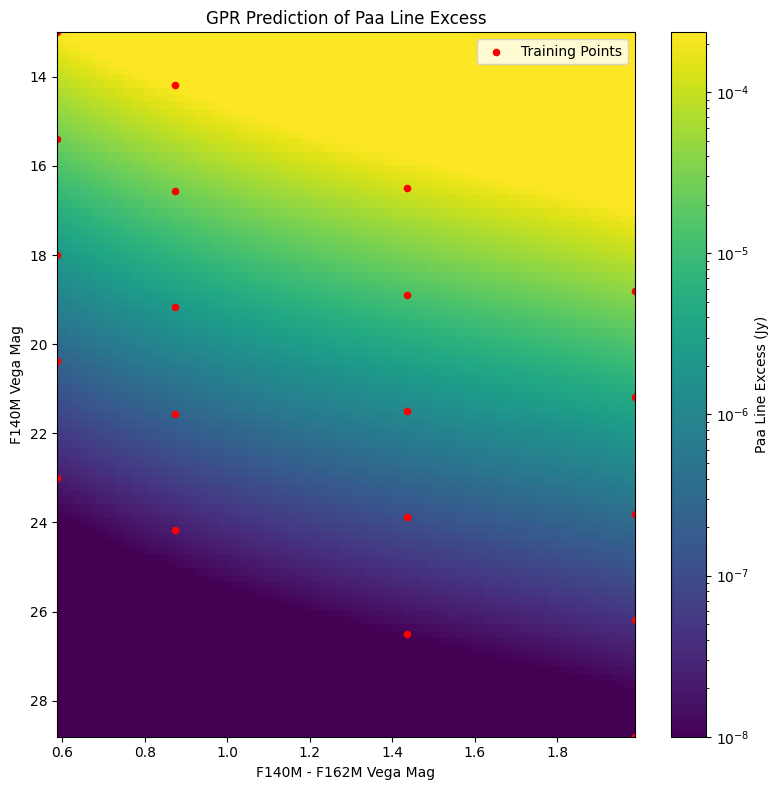

In [32]:
# plot the prediction
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1)
norm = LogNorm(vmin=1e-8, vmax=paa_excess_all.max())

im = ax.imshow(10**z_pred, extent=(xmin, xmax, ymin, ymax), origin='lower', aspect='auto', cmap='viridis', norm=norm)
ax.scatter(color_vals, mag_vals, c  ='red', s=20, label='Training Points')
ax.set_xlabel('F140M - F162M Vega Mag')
ax.set_ylabel('F140M Vega Mag')
ax.set_title('GPR Prediction of Paa Line Excess')
ax.legend()
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Paa Line Excess (Jy)')
ax.set_ylim(ax.get_ylim()[::-1])  # invert y-axis for magnitude
plt.tight_layout()
plt.show()



In [33]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89

def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err



catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')
print(catalog.colnames)
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}

f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = RL85_MWGC()
ext = CT06_MWLoc()
def plot_extvec_cmd(ax, color1, mag1, ext=RL85_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'{label}', linestyle='-', linewidth=2)



imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
filters = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(filters.keys())

def get_line_excess(catalog, narrow, wide):
    # --- Convert catalog MJy/sr → Jy ---
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))

    data_narrow = (catalog['flux_fit_' + narrow] * u.MJy/u.sr *
                   ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    data_wide = (catalog['flux_fit_' + wide] * u.MJy/u.sr *
                 ww_wide.proj_plane_pixel_area()).to(u.Jy)

    # --- Load filter curves ---
    tab_n = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    tab_w = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    wave_n = tab_n['Wavelength'] * u.AA
    trans_n = tab_n['Transmission']

    wave_w = tab_w['Wavelength'] * u.AA
    trans_w = tab_w['Transmission']

    # --- Interpolate narrow onto wide grid ---
    trans_n_interp = np.interp(wave_w.value, wave_n.value, trans_n)

    # --- Fractional overlap (proper integral) ---
    num = np.trapezoid(
    (trans_w / trans_w.max()) * (trans_n_interp / trans_n.max()),
    wave_w.value
    )
    den = np.trapezoid(trans_w / trans_w.max(), wave_w.value)
    f = num / den

    if np.isclose(f, 1.0):
        return None, None

    # --- Continuum & line (still in Jy = F_nu) ---
    cont_nu = (data_wide - data_narrow * f) / (1 - f)
    line_nu = data_narrow - cont_nu

    width_narrow = np.trapezoid(trans_n / trans_n.max(), wave_n.value) * u.AA

    # --- Equivalent Width ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ew = (line_nu / cont_nu) * width_narrow

    return line_nu.value, ew.to_value(u.AA)

paa_excess,  paa_excess_ew = get_line_excess(catalog, 'f187n', 'f182m')
bra_excess,  bra_excess_ew = get_line_excess(catalog, 'f405n', 'f410m')

print('paa_excess', paa_excess)

['skycoord_ref', 'skycoord_ref_filtername', 'sep_f140m', 'id_f140m', 'skycoord_f140m', 'flux_fit_f140m', 'flux_err_f140m', 'mask_f140m', 'qfit_f140m', 'cfit_f140m', 'local_bkg_f140m', 'roundness1_f140m', 'roundness2_f140m', 'sharpness_f140m', 'from_sat_catalog_f140m', 'std_ra_f140m', 'std_dec_f140m', 'nmatch_f140m', 'nmatch_good_f140m', 'flux_err_prop_f140m', 'sep_f480m', 'id_f480m', 'skycoord_f480m', 'flux_fit_f480m', 'flux_err_f480m', 'mask_f480m', 'qfit_f480m', 'cfit_f480m', 'local_bkg_f480m', 'roundness1_f480m', 'roundness2_f480m', 'sharpness_f480m', 'from_sat_catalog_f480m', 'std_ra_f480m', 'std_dec_f480m', 'nmatch_f480m', 'nmatch_good_f480m', 'flux_err_prop_f480m', 'sep_f560w', 'id_f560w', 'skycoord_f560w', 'flux_fit_f560w', 'flux_err_f560w', 'mask_f560w', 'qfit_f560w', 'cfit_f560w', 'local_bkg_f560w', 'roundness1_f560w', 'roundness2_f560w', 'sharpness_f560w', 'from_sat_catalog_f560w', 'std_ra_f560w', 'std_dec_f560w', 'nmatch_f560w', 'nmatch_good_f560w', 'flux_err_prop_f560w', 's

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


7.525093724479512e-11 deg2


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


7.52790883669383e-11 deg2


...

9.491458757317268e-10 deg2


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


7.524574264515582e-11 deg2


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T13:24:26.757' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.021' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202550 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191894.941 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '

paa_excess [           nan 2.77610496e-09            nan ...            nan
            nan            nan]


1.4 um 1.62 um 1.4 um
1.4 um 1.62 um 1.4 um
7.129363200000001 5.382330074074073 7.129363200000001
1.4 um 1.62 um 1.4 um
1.4 um 1.62 um 1.4 um
7.0412946428571415 5.4357638888888875 7.0412946428571415
1.4 um 1.62 um 1.4 um
1.4 um 1.62 um 1.4 um
7.129363200000001 5.382330074074073 7.129363200000001
1.4 um 1.62 um 1.4 um
1.4 um 1.62 um 1.4 um
6.673350218462829 5.377005929042962 6.673350218462829
1.4 um 1.62 um 1.4 um
1.4 um 1.62 um 1.4 um
6.877352882900731 5.15745734947461 6.877352882900731
1.4 um 1.62 um 1.4 um
1.4 um 1.62 um 1.4 um
6.826596279085869 4.00178720911646 6.826596279085869


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/home/t.yoo/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


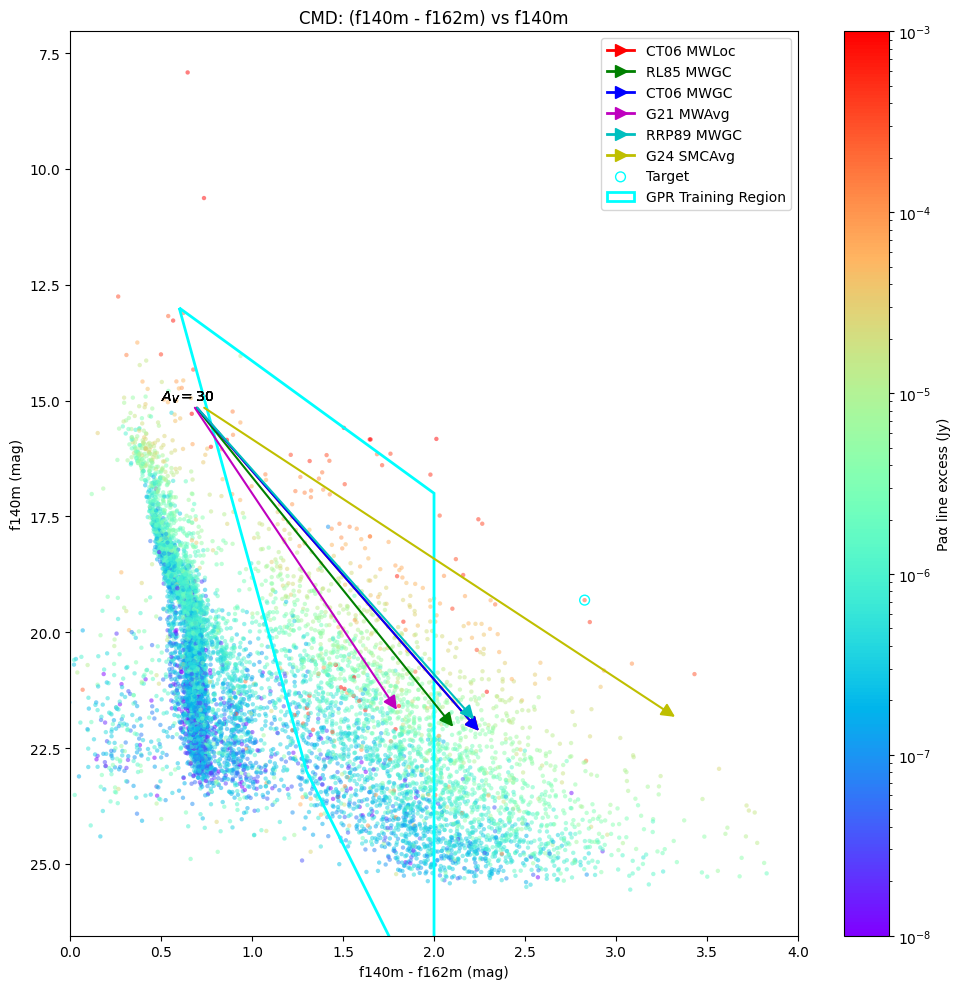

In [38]:
from astropy.coordinates import SkyCoord
ext = CT06_MWLoc()
# plot f140m-f162m color coded by f405n-f410m color
color = filters['f140m'][0] - filters['f162m'][0]
color_for_points = paa_excess

magnitude = filters['f140m'][0]


# Create plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

#hb = ax.hexbin(color_valid, mag_valid, gridsize=100, cmap='inferno', mincnt=1, bins='log')
#cb = fig.colorbar(hb, ax=ax, label='log(N)')
cmap = plt.get_cmap('rainbow')
norm = LogNorm(vmin=1e-8, vmax=1e-3)

ax.scatter(color.value, magnitude.value, s=10, c=color_for_points, cmap=cmap, alpha=0.5, edgecolor='none', norm=norm)
ax.set_xlabel('f140m - f162m (mag)')
ax.set_ylabel('f140m (mag)')
ax.set_title(f'CMD: (f140m - f162m) vs f140m')
ax.invert_yaxis()  # Invert y-axis for magnitude
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc, G21_MWAvg,RRP89_MWGC,G24_SMCAvg
colorlist = ['r', 'g', 'b', 'm', 'c', 'y']
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), CT06_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'CT06 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    plot_extvec_cmd(ax, color1=('f140m', 'f162m'), mag1=('f140m',), 
                     ext=ext_model, extvec_scale=30, color=c, 
                     color1_data=color, mag1_data=magnitude, start=(0.5, 15), label=labels)
  



#add colorbar for the color coding
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Paα line excess (Jy)')
plt.tight_layout()
#plt.savefig(f'{imgsavedir}cmd_{f1}_{f2}_vs_{mag_filter}.png', dpi=150)

skycoord_target = SkyCoord(ra=290.924875*u.deg, dec=14.5102237*u.deg, frame='icrs')
idx, d2d, _ = skycoord_target.match_to_catalog_sky(catalog['skycoord_ref'], nthneighbor=1)

ax.scatter(color[idx].value, magnitude[idx].value, s=50, edgecolor='cyan', facecolor='none', marker='o', label='Target')
ax.legend()

ax.set_xlim(0, 4)

# get x_min, x_max, y_min, y_max of the training data
vertices = [(0.6, 13), (1.3, 23), (2.0, 28.5), (2.0, 17 )]
from matplotlib.patches import Polygon
polygon = Polygon(vertices, closed=True, fill=False, edgecolor='cyan', linewidth=2, label='GPR Training Region')
ax.add_patch(polygon)
ax.legend()

from matplotlib.path import Path
training_region_path = Path(vertices)
idx1 = training_region_path.contains_points(np.array([color.value, magnitude.value]).T)
training_color = color.value[idx1]
training_mag = magnitude.value[idx1]
training_paa_excess = color_for_points[idx1]

plt.show()

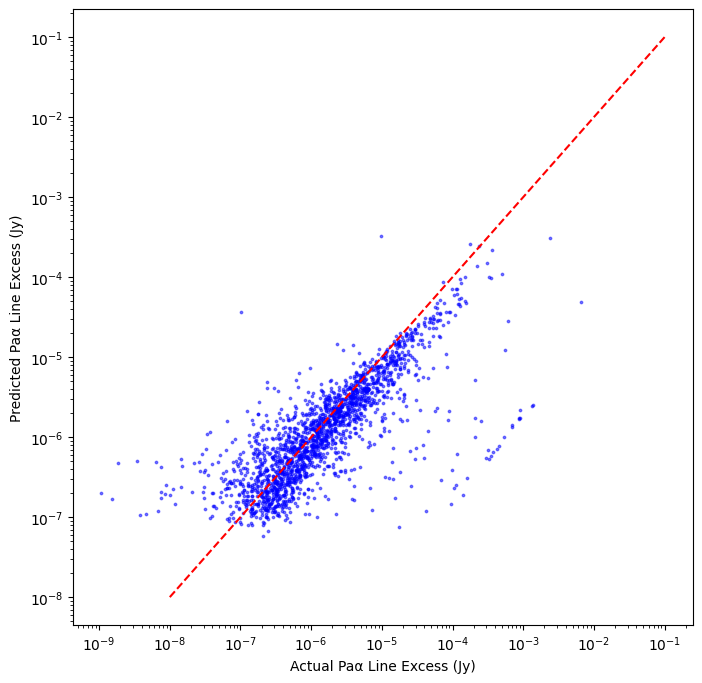

In [49]:
paa_excess_pred, paa_excess_std = gpr.predict(np.column_stack([training_color, training_mag]), return_std=True)

fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(1, 1, 1)
ax1.scatter(training_paa_excess, 10**paa_excess_pred, s=3, c='blue', label='Predicted vs Actual', alpha=0.5)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Actual Paα Line Excess (Jy)')
ax1.set_ylabel('Predicted Paα Line Excess (Jy)')
ax1.plot([1e-8,1e-1], [1e-8,1e-1], 'r--', label='1:1 Line')

[3.27292220e-07 5.68302990e-07 3.23181046e-05 ... 6.79612609e-06
            nan 5.14681278e-06]
[2.22072820e-07 4.34299525e-07 2.60505312e-05 ... 2.27949500e-07
 2.19876239e-07 1.86491455e-06]
[1.05219400e-07 1.34003465e-07 6.26757334e-06 ... 6.56817659e-06
            nan 3.28189823e-06]


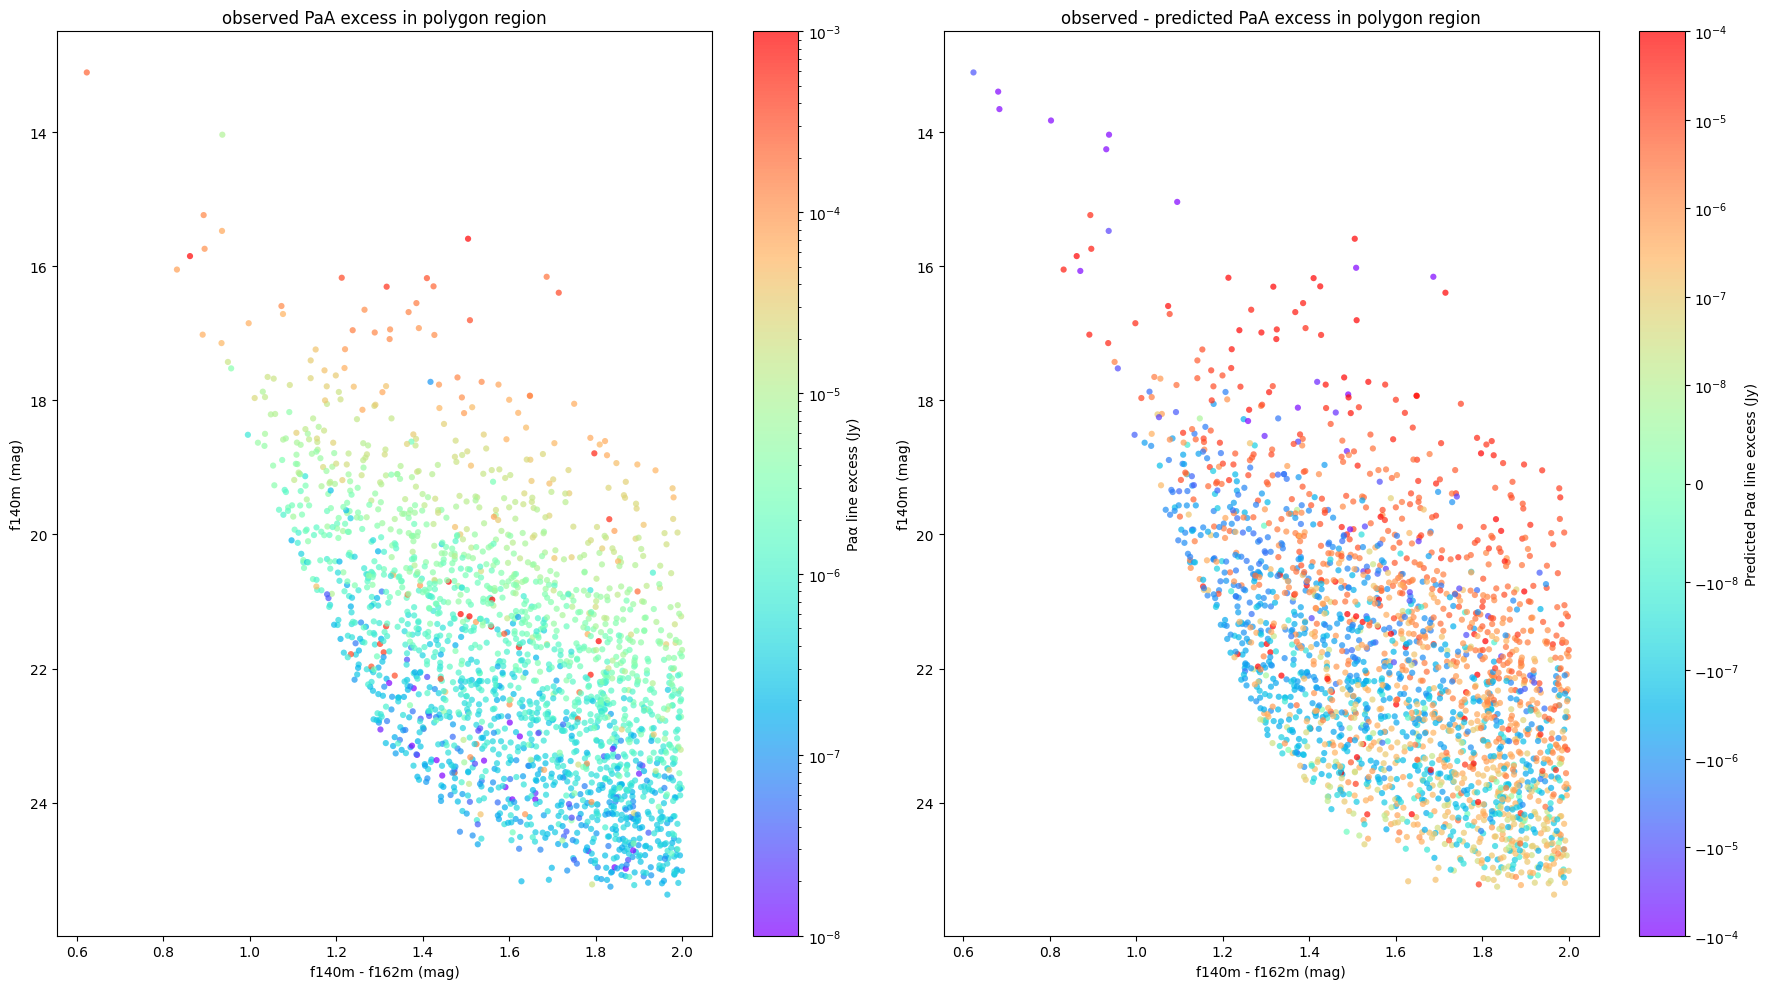

In [55]:
from matplotlib.colors import SymLogNorm

fig = plt.figure(figsize=(18, 10))
ax1 = fig.add_subplot(121)
cmap = plt.get_cmap('rainbow')
norm = LogNorm(vmin=1e-8, vmax=1e-3)
sc = ax1.scatter(training_color, training_mag, s=20, c=training_paa_excess, cmap=cmap, alpha=0.7, edgecolor='none', norm=norm)
ax1.set_xlabel('f140m - f162m (mag)')
ax1.set_ylabel('f140m (mag)')
ax1.set_title('observed PaA excess in polygon region')
ax1.invert_yaxis()
cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label('Paα line excess (Jy)')
ax2 = fig.add_subplot(122)

# training_paa_excess - z_pred
print(training_paa_excess)
print(10**paa_excess_pred)
paa_excess_sub = training_paa_excess - 10**paa_excess_pred
print(paa_excess_sub)
norm = SymLogNorm(
    linthresh=1e-8,     # range around zero that is linear
    linscale=1,      # size of linear region
    vmin=-1e-4, 
    vmax=1e-4,
    base=10
)

sc = ax2.scatter(training_color, training_mag, s=20, c=paa_excess_sub, cmap=cmap, alpha=0.7, edgecolor='none', norm=norm)
ax2.set_xlabel('f140m - f162m (mag)')
ax2.set_ylabel('f140m (mag)')
ax2.set_title('observed - predicted PaA excess in polygon region')
ax2.invert_yaxis()
cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label('Predicted Paα line excess (Jy)')
plt.tight_layout()
plt.show()
